<a href="https://colab.research.google.com/github/aahan-charak24/Deep-Learning-Mastery/blob/main/Optimization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import torch
import torch.optim as optim
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

<h1>Gabor Model optimization </h2>


In [9]:
#X
X = torch.arange(-30, 30, 0.1).view(-1, 1)

In [11]:
#gabor function
gabor_func = torch.sin(7 + 0.06 * 8 * X)* torch.exp((-(7+ 0.06*8*X)**2)/32.0)

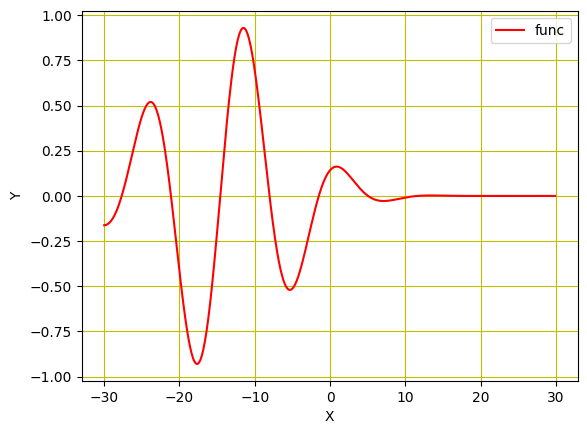

In [12]:
plt.plot(X.numpy(), gabor_func.numpy(), 'r', label = 'func')
plt.xlabel('X')
plt.ylabel('Y')
plt.grid('True', color = 'y')
plt.legend()
plt.show()

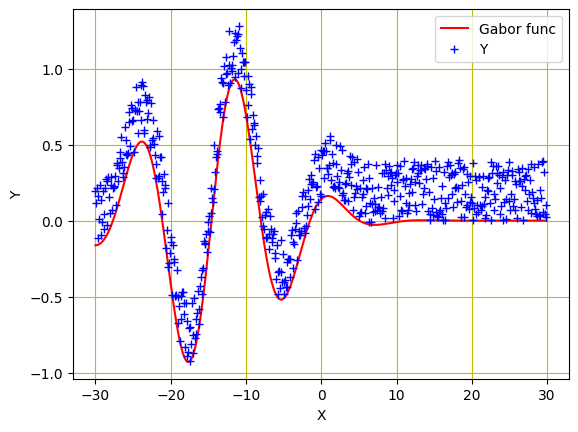

In [13]:
#noisy function to predict
Y = gabor_func + 0.4 * torch.rand(X.size())

plt.plot(X.numpy(), gabor_func.numpy(), 'r', label = 'Gabor func')
plt.plot(X.numpy(), Y.numpy(), 'b+', label = 'Y')
plt.xlabel('X')
plt.ylabel('Y')
plt.grid('True', color = 'y')
plt.legend()
plt.show()

<h1>Using SGD </h1>

In [68]:

class GaborModel(nn.Module):
  def __init__(self):
    super().__init__()
    self.backbone = nn.Sequential(
        nn.Linear(1, 128),
        nn.ReLU(),
        nn.Linear(128, 64),
        nn.ReLU(),
        nn.Linear(64, 1)
    )

  #forward pass
  def forward(self, x):
    x = self.backbone(x)
    return x



In [69]:
model = GaborModel()
print(model)

GaborModel(
  (backbone): Sequential(
    (0): Linear(in_features=1, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=1, bias=True)
  )
)


In [70]:
loss_fn = nn.MSELoss()
optimizer = optim.SGD(params = model.parameters(), lr = 0.001)

In [71]:

def train(model, n_epochs = 20, batch_size = 10, verbose = False):
  loss_list = []
  #go throught the training set
  for epoch in range(n_epochs):
    loss_batch = []
    for i in range(0, len(X), batch_size):
      #divide the batches
      X_batch = X[i:i+batch_size]
      Y_batch = Y[i:i+batch_size]
      #get predictions
      Y_pred = model(X_batch)
      #get the loss
      loss = loss_fn(Y_pred, Y_batch)
      loss_batch.append(loss.item())
      #backwards propagation
      optimizer.zero_grad()
      loss.backward()
      optimizer.step()

    #verbose
    if verbose:
      print(f'Epoch {epoch+1}. Loss{np.mean(loss_batch)}')

    loss_list.append(np.mean(loss_batch))

  return loss_list


In [72]:
history = train(model)

In [73]:
def plot_loss_fn(history, optim = 'SGD'):
  plt.plot(history, label = f"{optim}")
  plt.xlabel("Epochs")
  plt.ylabel("Loss")
  plt.legend()
  plt.grid('True', color = 'y')
  plt.title(f"Loss function for optimizer: {optim}")
  plt.show()


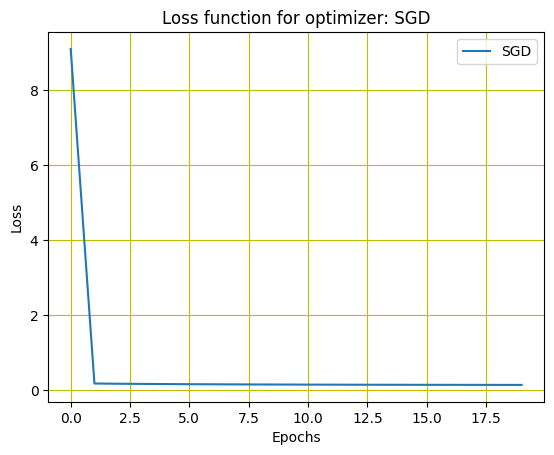

In [74]:
plot_loss_fn(history, 'SGD')

In [75]:
def get_MSE(model):
  y_pred = model(X)
  loss = loss_fn(y_pred, Y).item()
  return loss

In [76]:
mse = get_MSE(model)
print(f'Loss is {mse}')

Loss is 0.14182595908641815


<h1> Using SGD with momentum </h1>
Here, we accumulate some momentum, use previous mommentum kinda in a way of running average, which can push us out of saddle points etc

In [61]:
model2 = GaborModel()

In [77]:
optimizer = optim.SGD(params = model2.parameters(), lr = 0.001, momentum = 0.9)

In [78]:
history = train(model2)

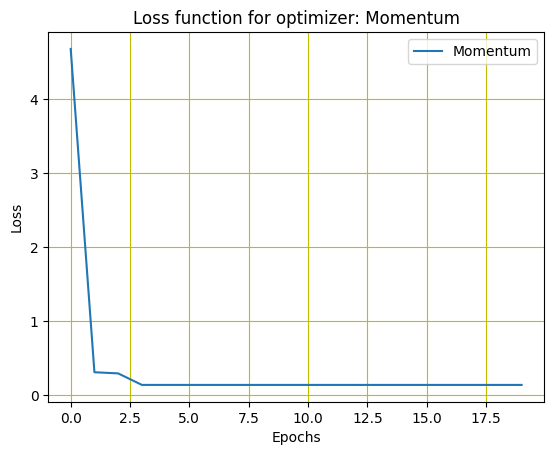

In [79]:
plot_loss_fn(history, 'Momentum')

In [80]:
mse = get_MSE(model2)
print(f'Loss is {mse}')

Loss is 0.13792741298675537


So, better loss for the same training epochs already

<h1>Nesterov Momentum </h1>
In a nutshell, jump forward using prev momentum and calc loss and derivative respectively at that point to get the new momentum then jump again using that momentum. So kinda looking ahead

In [81]:
model3 = GaborModel()
optimizer = optim.SGD(params = model3.parameters(), momentum = 0.9, nesterov = True, lr = 0.001)

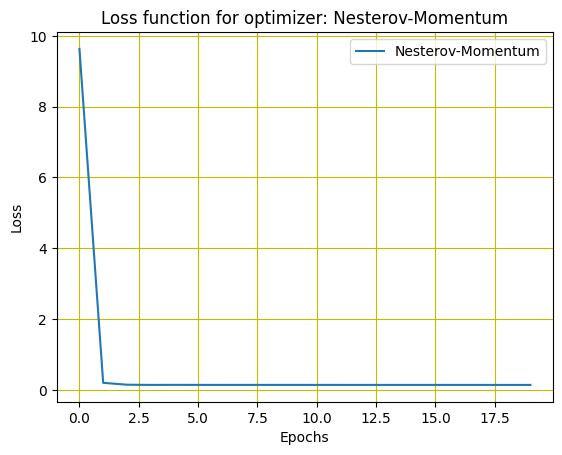

In [82]:
history = train(model3)
plot_loss_fn(history, 'Nesterov-Momentum')

In [84]:
mse = get_MSE(model3)
print(f'Loss is {mse}')

Loss is 0.1374836415052414


Very little improvement of momentum but still improvement